In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [10]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score

In [13]:
#Creating a dataset
X , y = make_moons(n_samples = 1000 , noise = 0.2 , random_state = 42)

In [14]:
#Deviding dataset to train and test
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [17]:
def evaluate_model(model , name):
    start = time.time()
    model.fit(X_train , y_train)
    end = time.time()

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test , y_pred)
    precision = precision_score(y_test , y_pred)
    recall = recall_score(y_test , y_pred)
    f1 = f1_score(y_test , y_pred)
    training_time = end - start

    print(name)
    print("Accuracy: " , accuracy)
    print("Precision: " , precision)
    print("Recall: " , recall)
    print("F1: " , f1)
    print("Training time: " , training_time) 

    return accuracy , precision , recall , f1 , training_time

Perceptron

In [18]:
perceptron = Perceptron(max_iter = 1000 , random_state = 42)
evaluate_model(perceptron , "Perceptron" )

Perceptron
Accuracy:  0.815
Precision:  0.752
Recall:  0.94
F1:  0.8355555555555556
Training time:  0.0056645870208740234


(0.815, 0.752, 0.94, 0.8355555555555556, 0.0056645870208740234)

MLP(2-4-1)

In [19]:
mlp_4 = MLPClassifier(hidden_layer_sizes = (4,) , max_iter = 2000 , random_state = 42)
evaluate_model(mlp_4 , "MLP 2-4-1")

MLP 2-4-1
Accuracy:  0.86
Precision:  0.86
Recall:  0.86
F1:  0.86
Training time:  0.9945745468139648


(0.86, 0.86, 0.86, 0.86, 0.9945745468139648)

MLP with my settings

In [22]:
neurons = [8 , 16 , 32 , 64 , 128]
for n in neurons:
    mlp = MLPClassifier(hidden_layer_sizes = (n,) , max_iter = 2000 , random_state = 42)
    evaluate_model(mlp , f"MLP 2-{n}-1  neurons")
    print("============================================")

MLP 2-8-1  neurons
Accuracy:  0.89
Precision:  0.875
Recall:  0.91
F1:  0.8921568627450981
Training time:  1.2332541942596436
MLP 2-16-1  neurons
Accuracy:  0.975
Precision:  0.9702970297029703
Recall:  0.98
F1:  0.9751243781094527
Training time:  3.475132465362549
MLP 2-32-1  neurons
Accuracy:  0.98
Precision:  0.98
Recall:  0.98
F1:  0.98
Training time:  2.702578067779541
MLP 2-64-1  neurons
Accuracy:  0.98
Precision:  0.98
Recall:  0.98
F1:  0.98
Training time:  3.158998489379883
MLP 2-128-1  neurons
Accuracy:  0.975
Precision:  0.9797979797979798
Recall:  0.97
F1:  0.9748743718592965
Training time:  3.182939052581787


Code for Table 3

In [26]:
depth = [
    (8,),
    (8,8),
    (8,8,8),
    (8,8,8,8)
]

for d in depth:
    mlp = MLPClassifier(hidden_layer_sizes = d , max_iter = 2000 , random_state = 42)
    evaluate_model(mlp , f"MLP 2-{d}-1")
    print("===================================")

MLP 2-(8,)-1
Accuracy:  0.89
Precision:  0.875
Recall:  0.91
F1:  0.8921568627450981
Training time:  1.2195732593536377
MLP 2-(8, 8)-1
Accuracy:  0.98
Precision:  0.98
Recall:  0.98
F1:  0.98
Training time:  2.4242324829101562
MLP 2-(8, 8, 8)-1
Accuracy:  0.985
Precision:  0.98989898989899
Recall:  0.98
F1:  0.9849246231155779
Training time:  2.495924234390259
MLP 2-(8, 8, 8, 8)-1
Accuracy:  0.98
Precision:  1.0
Recall:  0.96
F1:  0.9795918367346939
Training time:  1.8717503547668457


Task 4 Code

In [28]:
def plot_decision_boundry(model , title):
    h = 0.01 

    x_min , x_max = X[:, 0].min() - 1 , X[:, 0].max() + 1
    y_min , y_max = X[:, 1].min() - 1 , X[:, 1].max() + 1

    xx , yy = np.meshgrid(
        np.arange(x_min , x_max , h),
        np.arange(y_min , y_max , h)
    )

    Z = model.predict(np.c_[xx.ravel() , yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize = (6 , 5))
    plt.contour(xx , yy , Z , alpha = 0.4)
    plt.scatter(X[:, 0] , X[:, 1] , c = y , edgecolors = 'k')
    plt.title(title)
    plt.show()

Plot for Perceptron

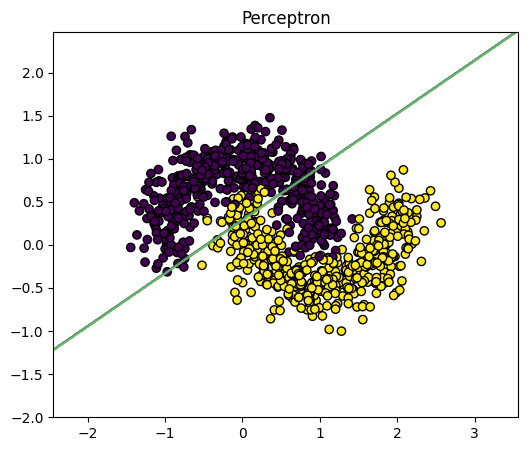

In [29]:
perceptron.fit(X_train , y_train)
plot_decision_boundry(perceptron , "Perceptron")

Plot for MLP(2-4-1) with worst accuracy

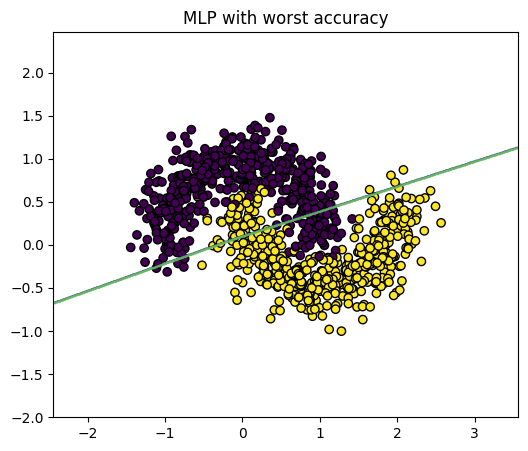

In [36]:
mlp_4.fit(X_train , y_train)
plot_decision_boundry(mlp_4 , "MLP with worst accuracy")

Plot for MLP(2-32-1 or 2-64-1) both of them have best accuracy

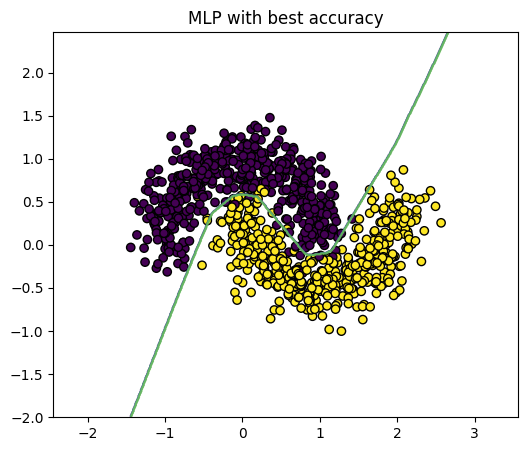

In [35]:
best_mlp = MLPClassifier(hidden_layer_sizes = (64,) , max_iter = 2000 , random_state = 42)
best_mlp.fit(X_train , y_train)
plot_decision_boundry(best_mlp , "MLP with best accuracy")